In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
without_pca = pd.read_csv("../results_without_pca.csv")
with_pca = pd.read_csv("../results_with_pca.csv")

without_pca["Approach"] = "Without PCA"
with_pca["Approach"] = "With PCA"

comparison_df = pd.concat(
    [without_pca, with_pca],
    ignore_index=True
)

In [3]:
comparison_df

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,RMSE Gap,Train R²,Test R²,R² Gap,Approach
0,Gradient Boosting,7216.049545,11302.608343,9322.216388,15652.862906,6330.646518,0.975277,0.921220,0.054057,Without PCA
1,HistGradientBoosting,6675.759117,11165.714215,9230.534620,15717.697829,6487.163209,0.975761,0.920566,0.055195,Without PCA
2,ElasticNet,11104.338058,12252.092959,15280.879026,16904.548543,1623.669517,0.933571,0.908117,0.025454,Without PCA
3,Lasso,11011.298146,12363.122042,15111.457140,16908.735408,1797.278267,0.935036,0.908072,0.026964,Without PCA
4,Ridge,11119.179715,12246.680824,15306.977911,16916.018037,1609.040126,0.933344,0.907992,0.025351,Without PCA
5,Linear Regression,11005.554857,12409.074670,15107.033789,16953.106502,1846.072712,0.935074,0.907589,0.027485,Without PCA
6,Random Forest,5575.132467,13220.315337,8746.027158,18326.864190,9580.837032,0.978239,0.892005,0.086234,Without PCA
7,AdaBoost,15704.091801,17365.349726,19918.776188,22482.758738,2563.982550,0.887127,0.837473,0.049655,Without PCA
8,KNN,0.000000,16304.958099,0.000000,23850.262038,23850.262038,1.000000,0.817100,0.182900,Without PCA
9,Decision Tree,9728.996468,18479.673733,13665.391536,25463.571923,11798.180388,0.946874,0.791519,0.155355,Without PCA


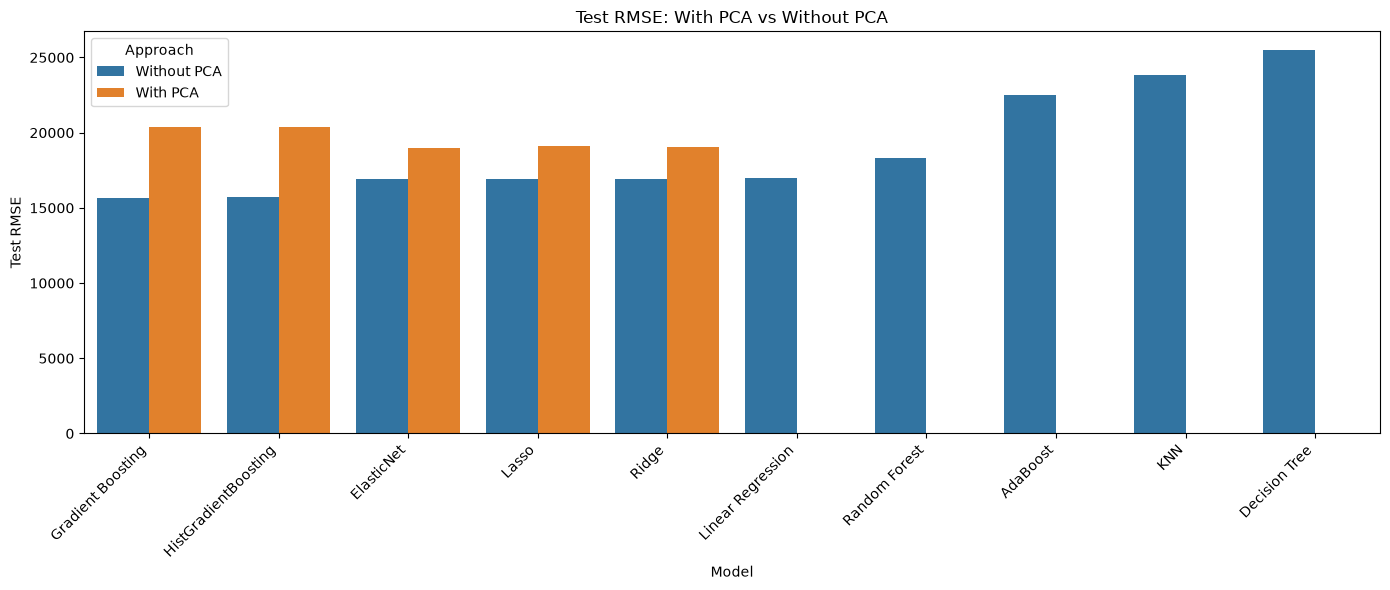

In [4]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Test RMSE",
    hue="Approach"
)

plt.title("Test RMSE: With PCA vs Without PCA")
plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

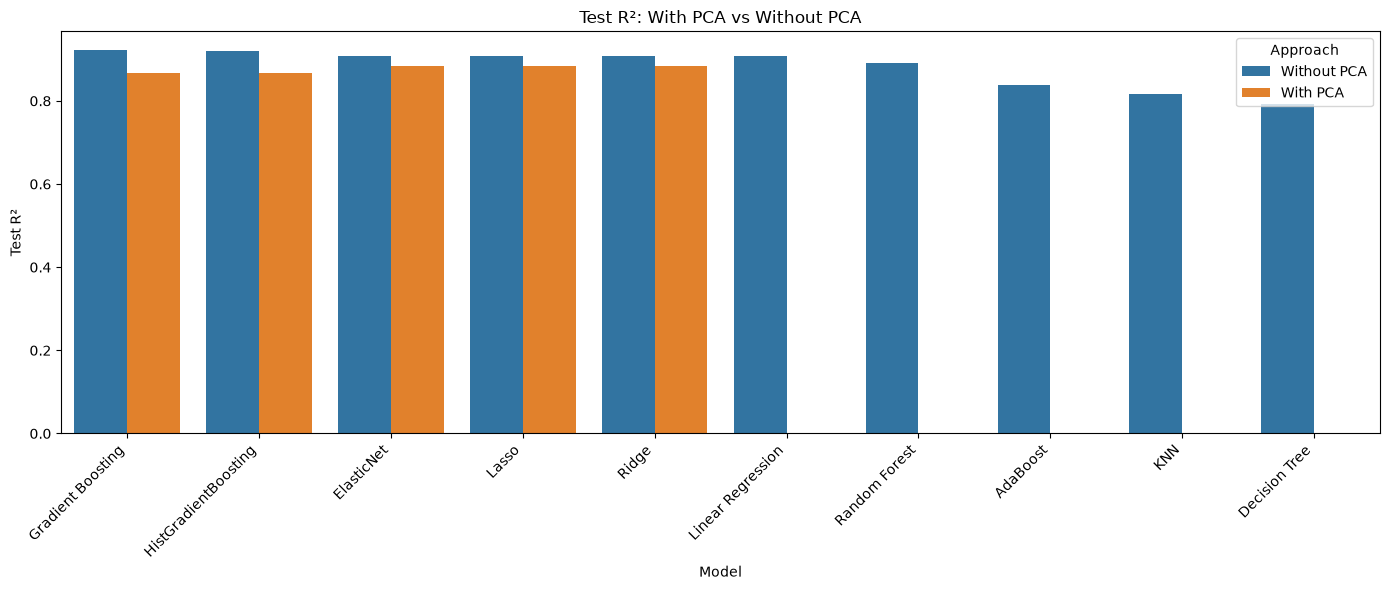

In [5]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Test R²",
    hue="Approach"
)

plt.title("Test R²: With PCA vs Without PCA")
plt.xlabel("Model")
plt.ylabel("Test R²")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

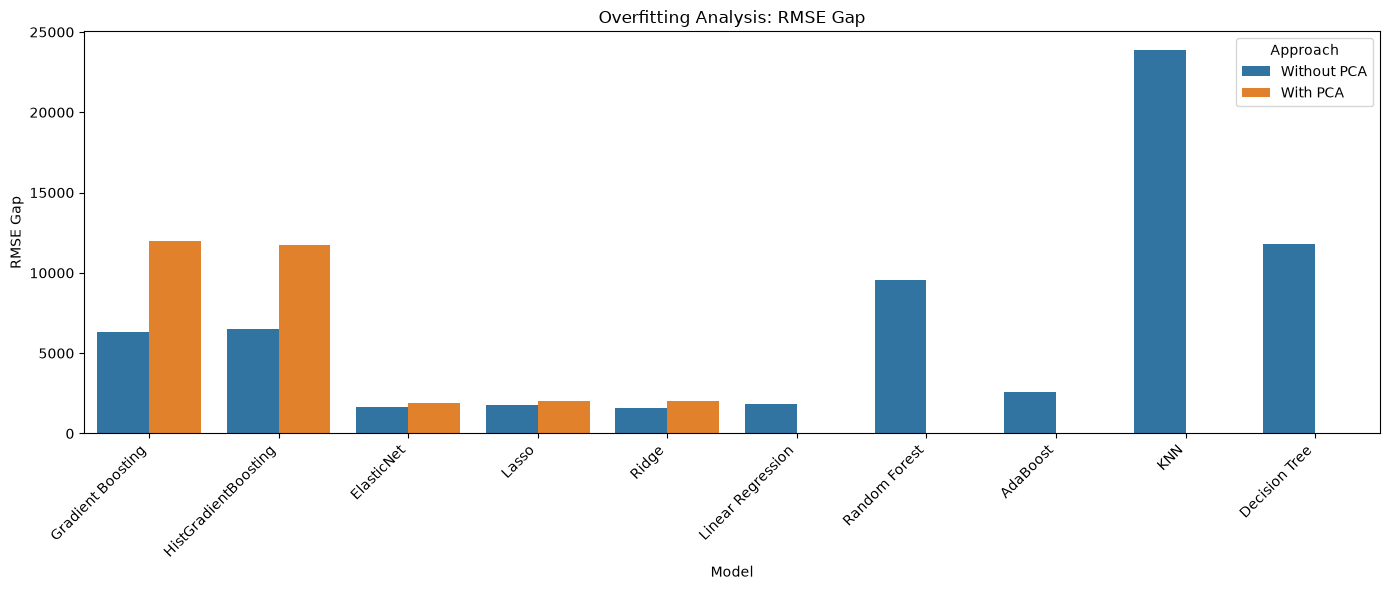

In [6]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="RMSE Gap",
    hue="Approach"
)

plt.title("Overfitting Analysis: RMSE Gap")
plt.xlabel("Model")
plt.ylabel("RMSE Gap")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [7]:
top_models = (
    comparison_df
    .sort_values("Test RMSE")
    .groupby("Approach")
    .head(2)
)

top_models

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,RMSE Gap,Train R²,Test R²,R² Gap,Approach
0,Gradient Boosting,7216.049545,11302.608343,9322.216388,15652.862906,6330.646518,0.975277,0.921220,0.054057,Without PCA
1,HistGradientBoosting,6675.759117,11165.714215,9230.534620,15717.697829,6487.163209,0.975761,0.920566,0.055195,Without PCA
10,ElasticNet,12555.910623,13680.906099,17096.599737,18977.918407,1881.318670,0.916846,0.884196,0.032650,With PCA
11,Ridge,12573.735862,13773.605079,17050.979564,19048.341465,1997.361901,0.917289,0.883335,0.033955,With PCA


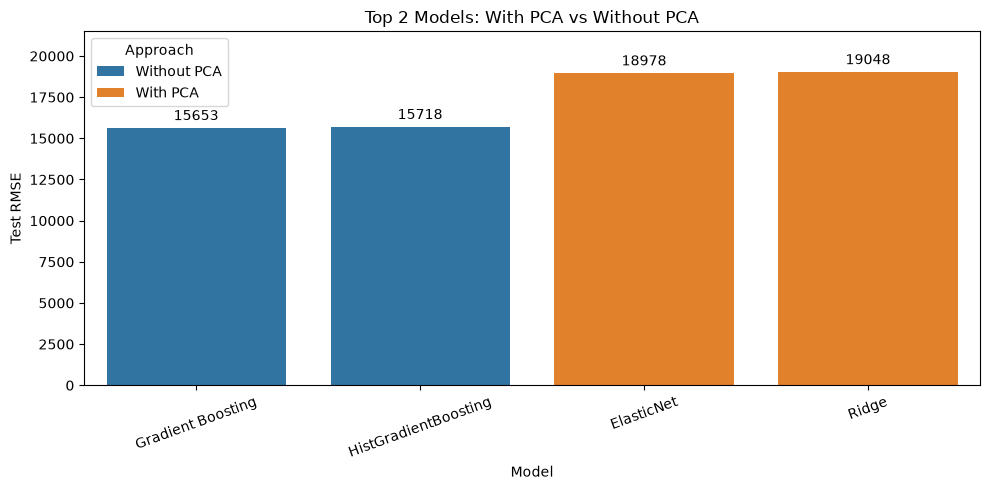

In [18]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=top_models,
    x="Model",
    y="Test RMSE",
    hue="Approach"
)

ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)
ax.bar_label(ax.containers[1], fmt="%.0f", padding=3)

plt.title("Top 2 Models: With PCA vs Without PCA")
plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.xticks(rotation=20)
plt.ylim(0, 21500)
plt.tight_layout()
plt.show()

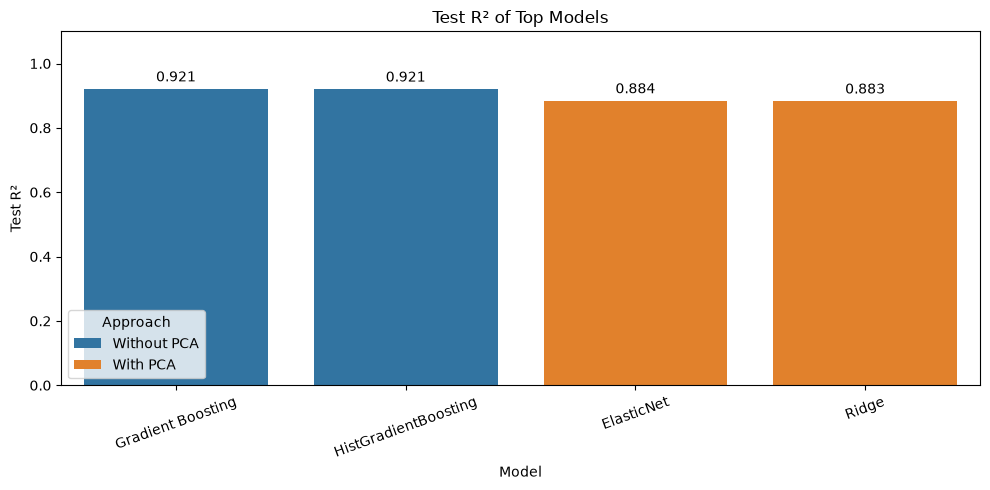

In [19]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=top_models,
    x="Model",
    y="Test R²",
    hue="Approach"
)

ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)
ax.bar_label(ax.containers[1], fmt="%.3f", padding=3)

plt.title("Test R² of Top Models")
plt.xlabel("Model")
plt.ylabel("Test R²")
plt.xticks(rotation=20)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

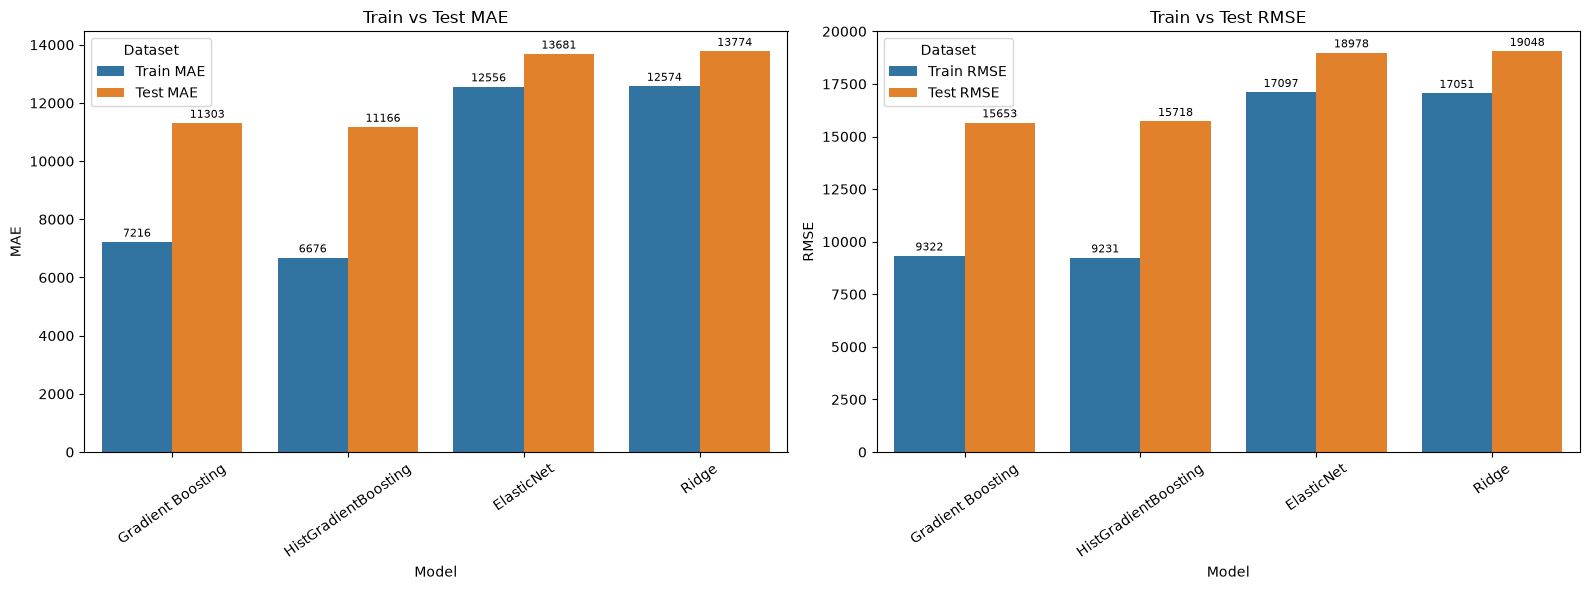

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MAE: Train vs Test
mae_data = top_models.melt(
    id_vars=["Model", "Approach"],
    value_vars=["Train MAE", "Test MAE"],
    var_name="Dataset",
    value_name="MAE"
)

sns.barplot(
    data=mae_data,
    x="Model",
    y="MAE",
    hue="Dataset",
    ax=axes[0]
)

axes[0].set_title("Train vs Test MAE")
axes[0].tick_params(axis="x", rotation=35)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=2, fontsize=8)

# RMSE: Train vs Test
rmse_data = top_models.melt(
    id_vars=["Model", "Approach"],
    value_vars=["Train RMSE", "Test RMSE"],
    var_name="Dataset",
    value_name="RMSE"
)

sns.barplot(
    data=rmse_data,
    x="Model",
    y="RMSE",
    hue="Dataset",
    ax=axes[1]
)

axes[1].set_title("Train vs Test RMSE")
axes[1].tick_params(axis="x", rotation=35)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=2, fontsize=8)

plt.tight_layout()
plt.show()

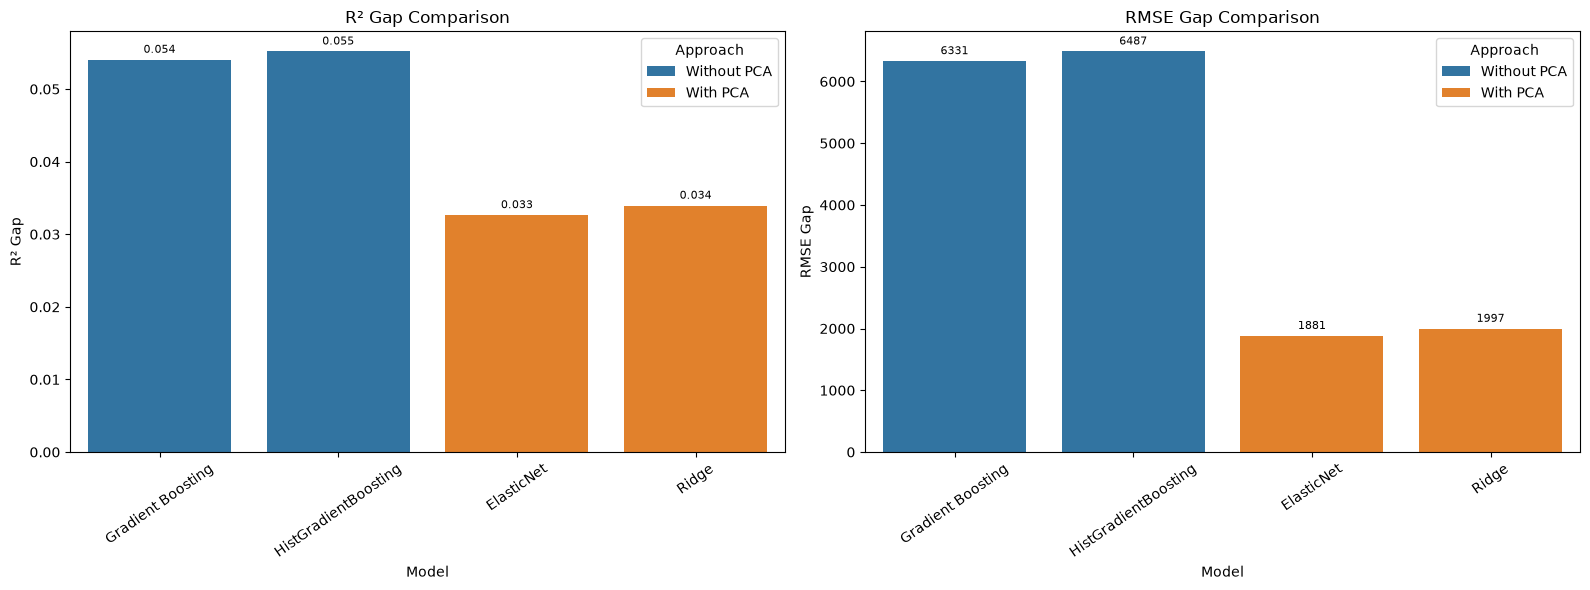

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² Gap
sns.barplot(
    data=top_models,
    x="Model",
    y="R² Gap",
    hue="Approach",
    ax=axes[0]
)

axes[0].set_title("R² Gap Comparison")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("R² Gap")
axes[0].tick_params(axis="x", rotation=35)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=3, fontsize=8)

# RMSE Gap
sns.barplot(
    data=top_models,
    x="Model",
    y="RMSE Gap",
    hue="Approach",
    ax=axes[1]
)

axes[1].set_title("RMSE Gap Comparison")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("RMSE Gap")
axes[1].tick_params(axis="x", rotation=35)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()

# Model Comparison: With PCA vs. Without PCA

## 1. Evaluation Criteria

The models were evaluated using MAE, RMSE, and \(R^2\) on both training and test datasets.

- **MAE (Mean Absolute Error):** Measures the average absolute difference between actual and predicted house prices. Lower values indicate better predictive accuracy.
- **RMSE (Root Mean Squared Error):** Measures prediction error while penalizing large errors more heavily. Lower values are preferred.
- **\(R^2\) Score:** Measures how much of the variation in house prices is explained by the model. Higher values are preferred.
- **RMSE Gap:** The difference between training RMSE and test RMSE. A smaller gap can indicate more consistent performance across datasets.
- **\(R^2\) Gap:** The difference between training and test \(R^2\). A smaller gap can indicate a smaller generalization gap.

A smaller gap alone does not guarantee a better model. Test-set performance must also be considered.

## 2. Best Models Without PCA

### Gradient Boosting

| Metric | Value |
|---|---:|
| Train MAE | 7,216.05 |
| Test MAE | 11,302.61 |
| Train RMSE | 9,322.22 |
| Test RMSE | 15,652.86 |
| RMSE Gap | 6,330.65 |
| Train \(R^2\) | 0.9753 |
| Test \(R^2\) | 0.9212 |
| \(R^2\) Gap | 0.0541 |

**Why it stands out**

- Achieves the lowest Test RMSE among all evaluated models.
- Achieves the highest Test \(R^2\) in the comparison.
- Captures nonlinear relationships between housing characteristics and sale prices.
- Shows a noticeable training–test gap, so some overfitting may be present.

### HistGradientBoosting

| Metric | Value |
|---|---:|
| Train MAE | 6,675.76 |
| Test MAE | 11,165.71 |
| Train RMSE | 9,230.53 |
| Test RMSE | 15,717.70 |
| RMSE Gap | 6,487.16 |
| Train \(R^2\) | 0.9758 |
| Test \(R^2\) | 0.9206 |
| \(R^2\) Gap | 0.0552 |

**Why it stands out**

- Achieves the lowest Test MAE among all evaluated models.
- Provides a Test RMSE and \(R^2\) very close to Gradient Boosting.
- Offers another strong nonlinear modeling option.
- Has a slightly larger RMSE Gap than Gradient Boosting.

## 3. Best Models With PCA

### ElasticNet

| Metric | Value |
|---|---:|
| Train MAE | 12,555.91 |
| Test MAE | 13,680.91 |
| Train RMSE | 17,096.60 |
| Test RMSE | 18,977.92 |
| RMSE Gap | 1,881.32 |
| Train \(R^2\) | 0.9168 |
| Test \(R^2\) | 0.8842 |
| \(R^2\) Gap | 0.0327 |

**Why it stands out**

- Achieves the lowest Test RMSE and highest Test \(R^2\) among the evaluated PCA models.
- Has a relatively small training–test gap.
- Combines L1 and L2 regularization, which can help control model complexity.
- Its test error is higher than that of the strongest models without PCA.

### Ridge Regression

| Metric | Value |
|---|---:|
| Train MAE | 12,573.74 |
| Test MAE | 13,773.61 |
| Train RMSE | 17,050.98 |
| Test RMSE | 19,048.34 |
| RMSE Gap | 1,997.36 |
| Train \(R^2\) | 0.9173 |
| Test \(R^2\) | 0.8833 |
| \(R^2\) Gap | 0.0340 |

**Why it stands out**

- Performs closely to ElasticNet on the test set.
- Uses L2 regularization to reduce the impact of large coefficients.
- Has a relatively small training–test gap.
- Does not match ElasticNet's test metrics in this comparison.

## 4. Overall Comparison

| Criterion | Without PCA | With PCA |
|---|---|---|
| Best model by Test RMSE | Gradient Boosting | ElasticNet |
| Best Test RMSE | 15,652.86 | 18,977.92 |
| Best Test MAE | HistGradientBoosting: 11,165.71 | ElasticNet: 13,680.91 |
| Best Test \(R^2\) | Gradient Boosting: 0.9212 | ElasticNet: 0.8842 |
| Generalization gap | Larger for the top models | Smaller for the top models |
| Model characteristics | Captures nonlinear relationships | Reduces dimensionality before modeling |

### Interpretation

The models without PCA achieve better predictive accuracy on the test set. Gradient Boosting has the lowest Test RMSE and highest Test \(R^2\), while HistGradientBoosting has the lowest Test MAE.

The PCA approach produces smaller training–test gaps for its leading models, but its test errors are higher. This suggests that the smaller gap does not compensate for the loss in predictive accuracy in the current experiments.

## 5. Advantages and Disadvantages

### Without PCA

**Advantages**
- Retains the original feature representation.
- Allows tree-based models to learn nonlinear patterns and feature interactions.
- Achieves the strongest test-set performance in these experiments.
- Avoids losing information through dimensionality reduction.

**Disadvantages**
- Tree-based models show larger training–test gaps.
- More complex models may require careful tuning to control overfitting.
- Keeping all features can increase computational cost in some workflows.

### With PCA

**Advantages**
- Reduces the number of dimensions used by the downstream model.
- Can reduce redundancy among correlated numerical features.
- May make some modeling workflows more compact.
- The leading models show smaller training–test gaps in this comparison.

**Disadvantages**
- Principal components are combinations of original features and are harder to interpret.
- Some predictive information may be lost during dimensionality reduction.
- PCA does not guarantee better generalization or lower test error.
- The evaluated PCA models have higher test errors than the leading models without PCA.

## 6. Final Conclusion

Based on the current test-set results, **Gradient Boosting without PCA** is the leading model for minimizing RMSE and maximizing \(R^2\). **ElasticNet with PCA** is the leading model among the evaluated PCA models.

The results indicate that PCA did not improve predictive accuracy for this particular set of models and settings. However, PCA remains a useful dimensionality-reduction technique in other settings, especially when feature redundancy or computational efficiency is important.

For the final model selection, Gradient Boosting without PCA is the primary candidate, while ElasticNet with PCA provides a useful comparison baseline. Before deployment, the selected models should be checked with cross-validation and, if possible, evaluated on an untouched holdout set.

*Note: These conclusions apply to the reported metrics and experimental setup. They do not establish that PCA is generally inferior, nor do they identify which original housing features are most important.*

In [ ]:
import joblib

joblib.dump(
    best_gb,
    "../models/gradient_boosting_without_pca.joblib"
)

joblib.dump(
    best_elasticnet,
    "../models/elasticnet_with_pca.joblib"
)